In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

In [4]:
df = pd.read_csv('/content/Mall_Customers.csv')
df.columns = df.columns.str.strip()   # fix trailing spaces in column names

x = df[['Annual Income (k$)', 'Spending Score']].values
# We use just Income + Spending — the two most meaningful columns
# This is where the 5 groups live as you already saw in the scatter plot


In [5]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

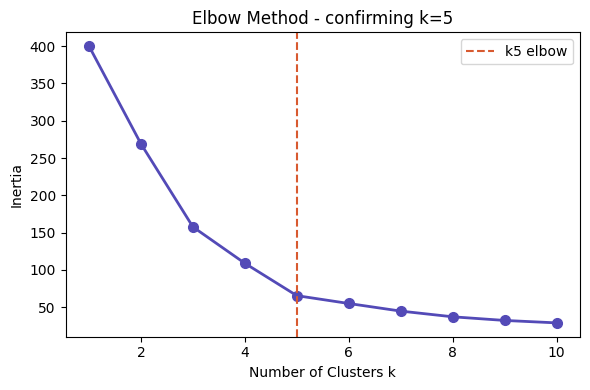

In [6]:
# ══════════════════════════════════════════════
# STEP 1 — Elbow Method
# ══════════════════════════════════════════════

inertias = []
for k in range(1,11):
  km = KMeans(n_clusters=k, random_state=32, n_init=10)
  km.fit(x_scaled)
  inertias.append(km.inertia_)


plt.figure(figsize=(6,4))
plt.plot(range(1,11), inertias, 'o-', color='#534AB7', linewidth=2, markersize=7)
plt.axvline(x=5, color='#D85A30', linestyle='--', label='k5 elbow')
plt.xlabel("Number of Clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method - confirming k=5")
plt.legend()
plt.tight_layout()
plt.show()

Cluster averages:
         Annual Income (k$)  Spending Score
Cluster                                    
0                      55.3            49.5
1                      86.5            82.1
2                      25.7            79.4
3                      88.2            17.1
4                      26.3            20.9


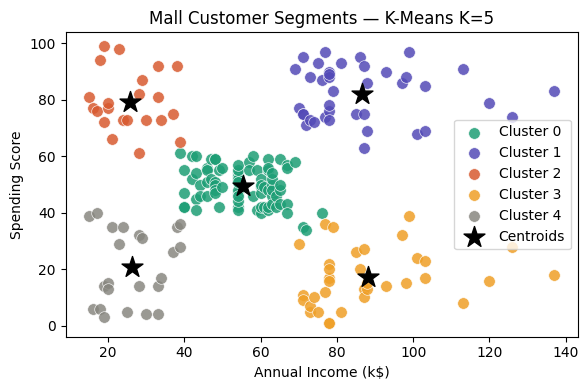

In [12]:
# ══════════════════════════════════════════════
# STEP 2 — K-Means with K=5
# ══════════════════════════════════════════════
km = KMeans(n_clusters=5, random_state=42, n_init=10)
km.fit(x_scaled)
df['Cluster'] = km.labels_

# ── Cluster averages — this tells us who each group is ───────
print("Cluster averages:")
summary = df.groupby('Cluster')[['Annual Income (k$)',
                                  'Spending Score']].mean().round(1)
print(summary)

# ── Plot the clusters ─────────────────────────────────────────
colors  = ['#1D9E75','#534AB7','#D85A30','#EF9F27','#888780']
names   = ['C0','C1','C2','C3','C4']

plt.figure(figsize=(6, 4))
for i in range(5):
    mask = df['Cluster'] == i
    plt.scatter(x[mask, 0], x[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                s=70, alpha=0.85, edgecolors='white', linewidth=0.5)


plt.scatter(scaler.inverse_transform(km.cluster_centers_)[:, 0],
            scaler.inverse_transform(km.cluster_centers_)[:, 1],
            c='black', marker='*', s=250, label='Centroids', zorder=5)


plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Mall Customer Segments — K-Means K=5')
plt.legend()
plt.tight_layout()
plt.show()



Unusual customers found: 10
     Annual Income (k$)  Spending Score  Cluster
11                   19              99        2
19                   23              98        2
185                  99              97        1
192                 113               8        3
193                 113              91        1
195                 120              79        1
196                 126              28        3
197                 126              74        1
198                 137              18        3
199                 137              83        1


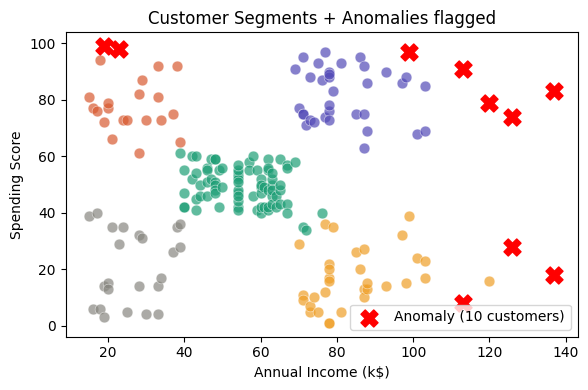

In [15]:
# ══════════════════════════════════════════════
# STEP 3 — Isolation Forest
# ══════════════════════════════════════════════
iso = IsolationForest(contamination=0.05, random_state=42)
iso.fit(x_scaled)
df['Anomaly'] = iso.predict(x_scaled)

anomalies = df[df['Anomaly'] == -1]
print(f"\nUnusual customers found: {len(anomalies)}")
print(anomalies[['Annual Income (k$)','Spending Score','Cluster']])

# ── Plot with anomalies highlighted ──────────────────────────
plt.figure(figsize=(6, 4))
for i in range(5):
    mask = (df['Cluster'] == i) & (df['Anomaly'] == 1)
    plt.scatter(x[mask, 0], x[mask, 1],
                c=colors[i], s=60, alpha=0.7,
                edgecolors='white', linewidth=0.4)

anomaly_mask = df['Anomaly'] == -1
plt.scatter(x[anomaly_mask, 0], x[anomaly_mask, 1],
            c='red', s=150, marker='X',
            label=f'Anomaly ({anomaly_mask.sum()} customers)', zorder=5)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segments + Anomalies flagged')
plt.legend()
plt.tight_layout()
plt.show()